## **REGRESION LINEAL MULTIPLE**
La regresión lineal múltiple es un algoritmo de aprendizaje supervisado utilizado para predecir el valor de una variable dependiente a partir de dos o más variables independientes. Su objetivo es encontrar la relación lineal que mejor explique el comportamiento de la variable objetivo mediante una ecuación matemática, donde cada variable independiente aporta un coeficiente que representa su influencia sobre el resultado. Este modelo es ampliamente utilizado para realizar predicciones y analizar el impacto que tienen múltiples factores sobre una misma variable.

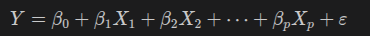

In [ ]:
import pandas as pd #Acceder al dataset
import numpy as np
from sklearn.linear_model import LinearRegression #Regresion Lineal Multiple
from sklearn.model_selection import train_test_split #Entrenamiento del modelo
import seaborn as sns
import matplotlib.pyplot as plt #realización de graficas del modelo
from sklearn import metrics #importar las metricas
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
#cargar el dataset
df = pd.read_csv('data_final.csv')

In [ ]:
#mostrar las variables del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16312 entries, 0 to 16311
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   odometer                16312 non-null  float64
 1   price                   16312 non-null  float64
 2   size                    16312 non-null  float64
 3   title_status            16312 non-null  float64
 4   year                    16312 non-null  int64  
 5   condition_encoding      16312 non-null  float64
 6   cylinders_int           16312 non-null  float64
 7   fuel_diesel             16312 non-null  float64
 8   fuel_electric           16312 non-null  float64
 9   fuel_gas                16312 non-null  float64
 10  fuel_hybrid             16312 non-null  float64
 11  drive_4wd               16312 non-null  float64
 12  drive_fwd               16312 non-null  float64
 13  drive_rwd               16312 non-null  float64
 14  transmission_automatic  16312 non-null

In [ ]:
#definir las variables dependientes e independientes
X = df.drop(columns=["price"]) #variables independientes
y = df['price'] #variables dependientes

In [ ]:
#definir las variables de entrenamiento y prueba
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.15,random_state=42)

In [ ]:
#creacion del modelo
modelo = LinearRegression()
modelo.fit(X_train,y_train)

LinearRegression()

In [ ]:
#realizar prediciones del modelo
y_pred = modelo.predict(X_test)

In [ ]:
#metricas a evaluar de los modelos
def metrics_model(y_test,y_pred):
  mae = mean_absolute_error(y_test, y_pred)
  mse = mean_squared_error(y_test, y_pred)
  rmse = np.sqrt(mean_squared_error(y_test, y_pred))
  r2 = r2_score(y_test, y_pred)
  print(f'MAE: {mae}')
  print(f'MSE: {mse}')
  print(f'RMSE: {rmse}')
  print(f'R2: {r2}')
  #return mae,mse,rmse,r2

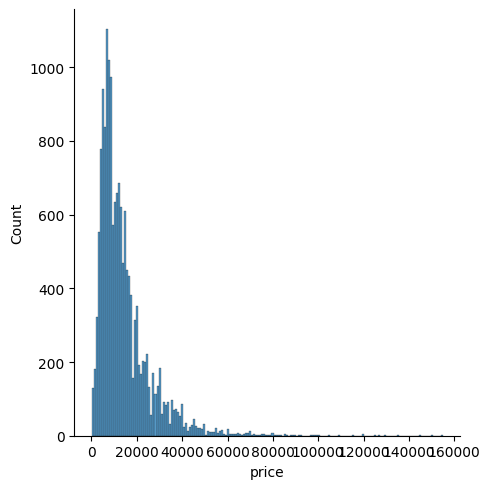

In [ ]:
#distribucion de los datos
sns.displot(df['price'])

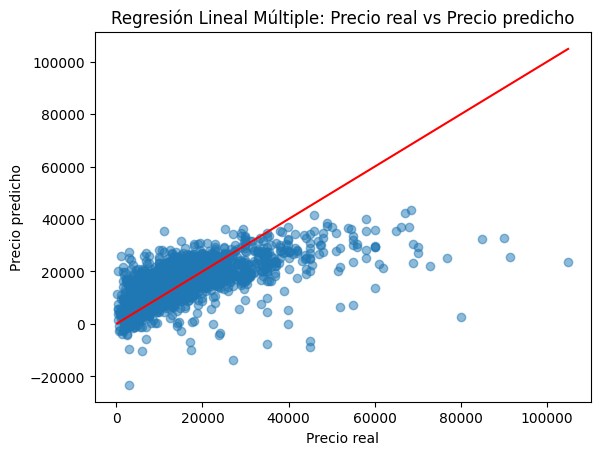

In [ ]:
#mostrar una grafica del precio real vs precio del modelo
plt.scatter(y_test, y_pred, alpha=0.5)

# Línea ideal (predicción perfecta)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Regresión Lineal Múltiple: Precio real vs Precio predicho")

plt.show()

In [ ]:
#Metricas del modelo
metrics_model(y_test,y_pred)

MAE: 5443.468527168028
MSE: 72028513.34458861
RMSE: 8486.96137287007
R2: 0.4315046532484883


## **REGRESION RIDGE**
La regresión Ridge es una variante de la regresión lineal múltiple que incorpora una técnica de regularización para mejorar la capacidad de generalización del modelo. Su principal característica es que añade una penalización a los coeficientes de las variables independientes, evitando que estos tomen valores demasiado grandes y reduciendo el riesgo de sobreajuste (overfitting). Este modelo es especialmente útil cuando existen muchas variables o cuando algunas de ellas están altamente correlacionadas, ya que produce predicciones más estables sin eliminar ninguna variable del modelo.

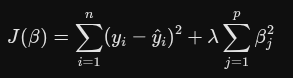

In [ ]:
#importar librerias
from sklearn.linear_model import Ridge

In [ ]:
#definir las variables de entrenamiento
X_train_R,X_test_R,y_train_R,y_test_R = train_test_split(X,y,test_size=0.15,random_state=42)

In [ ]:
#crear el modelo
model_Ridge = Ridge(alpha=7,solver='cholesky',tol=0.0001,random_state=42)
#entrenar el modelo
model_Ridge.fit(X_train_R,y_train_R)

Ridge(alpha=7, random_state=42, solver='cholesky')

In [ ]:
#prediccion del modelo
y_pred_R = model_Ridge.predict(X_test_R)

In [ ]:
#ver las metricas
metrics_model(y_test_R,y_pred_R)

MAE: 5441.116590462464
MSE: 71980296.11665918
RMSE: 8484.120232331647
R2: 0.4318852146184001


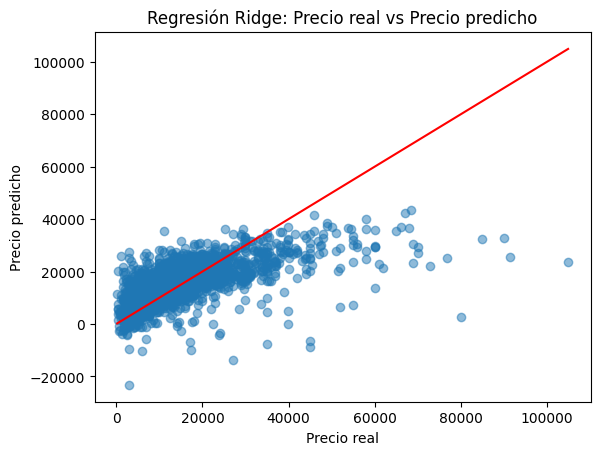

In [ ]:
#mostrar una grafica del precio real vs precio del modelo
plt.scatter(y_test_R, y_pred_R, alpha=0.5)

# Línea ideal (predicción perfecta)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Regresión Ridge: Precio real vs Precio predicho")

plt.show()

## **REGRESION LASSO**
La regresión Lasso es una variante de la regresión lineal que incorpora una técnica de regularización mediante una penalización sobre los coeficientes del modelo. A diferencia de la regresión Ridge, Lasso puede reducir algunos coeficientes exactamente a cero, eliminando automáticamente las variables que aportan poca información. Esto permite obtener modelos más simples, fáciles de interpretar y con menor riesgo de sobreajuste, siendo especialmente útil cuando se trabaja con un gran número de variables independientes.

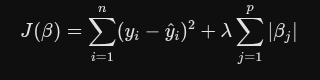

In [ ]:
#importar libreria
from sklearn.linear_model import Lasso

In [ ]:
#definir las variables
X_train_L,X_test_L,y_train_L,y_test_L = train_test_split(X,y,test_size=0.15,random_state=42)

In [ ]:
#crear el modelo
modelo_Lasso = Lasso(alpha=0.1,precompute=True,positive=True,selection='random')
#entrenar el modelo
modelo_Lasso.fit(X_train_L,y_train_L)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 588947119065.7274, tolerance: 197050034.2452556
  model = cd_fast.enet_coordinate_descent_gram(


Lasso(alpha=0.1, positive=True, precompute=True, selection='random')

In [ ]:
#prediciones del modelo
y_pred_L = modelo_Lasso.predict(X_test_L)

In [ ]:
#ver la metricas
metrics_model(y_test_L,y_pred_L)

MAE: 5680.84984683855
MSE: 77350034.26895118
RMSE: 8794.886825249725
R2: 0.38950378799852936


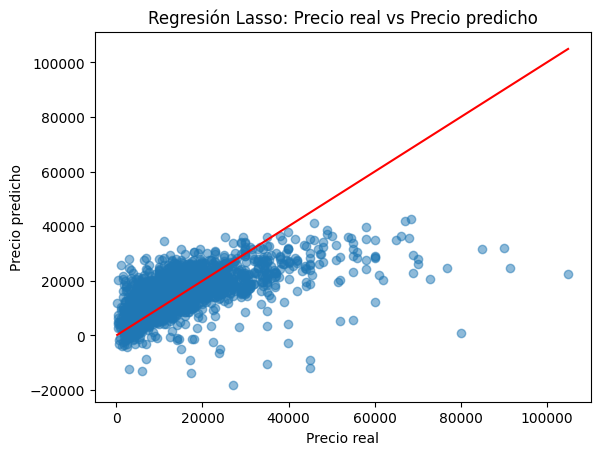

In [ ]:
#mostrar una grafica del precio real vs precio del modelo
plt.scatter(y_test_L, y_pred_L, alpha=0.5)

# Línea ideal (predicción perfecta)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Regresión Lasso: Precio real vs Precio predicho")

plt.show()

## **REGRESION ELASTIC NET**
La regresión Elastic Net es un modelo de regresión lineal que combina las técnicas de regularización de Ridge y Lasso. Su objetivo es mejorar la capacidad de generalización del modelo al reducir el riesgo de sobreajuste y, al mismo tiempo, realizar una selección de variables cuando es necesario. Gracias a esta combinación, Elastic Net es especialmente útil en conjuntos de datos con un gran número de variables o cuando existen variables altamente correlacionadas, logrando un equilibrio entre la estabilidad de Ridge y la capacidad de simplificación de Lasso.

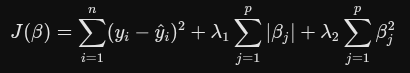

In [ ]:
#importar libreria
from sklearn.linear_model import ElasticNet

In [ ]:
#definir las variables
X_train_E,X_test_E,y_train_E,y_test_E = train_test_split(X,y,test_size=0.15,random_state=42)

In [ ]:
#crear el modelo
modelo_ElasticNet = ElasticNet(alpha=0.1,l1_ratio=0.9,selection='random',random_state=42)
#entrenar el modelo
modelo_ElasticNet.fit(X_train_E,y_train_E)

ElasticNet(alpha=0.1, l1_ratio=0.9, random_state=42, selection='random')

In [ ]:
#realizar las prediciones
y_pred_E = modelo_ElasticNet.predict(X_test_E)

In [ ]:
#ver la metricas
metrics_model(y_test_E,y_pred_E)

MAE: 5431.902637727446
MSE: 71981622.78807685
RMSE: 8484.198417533435
R2: 0.43187474367442824


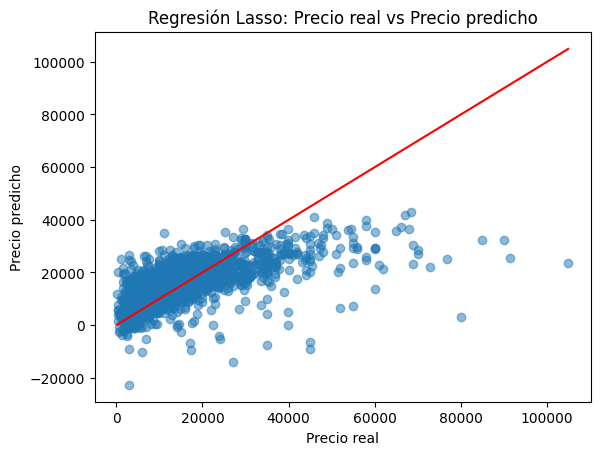

In [ ]:
#mostrar una grafica del precio real vs precio del modelo
plt.scatter(y_test_E, y_pred_E, alpha=0.5)

# Línea ideal (predicción perfecta)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Regresión Lasso: Precio real vs Precio predicho")

plt.show()

## **RANDOM FOREST REGRESSOR**
El Random Forest Regressor es un algoritmo de aprendizaje supervisado utilizado para predecir valores numéricos mediante la combinación de múltiples árboles de decisión. En lugar de basarse en un solo árbol, el modelo construye un conjunto de árboles utilizando diferentes muestras de los datos y un subconjunto aleatorio de variables. Posteriormente, la predicción final se obtiene calculando el promedio de las predicciones realizadas por todos los árboles. Este enfoque reduce el riesgo de sobreajuste, mejora la precisión del modelo y permite capturar relaciones complejas y no lineales entre las variables, siendo especialmente útil para problemas de predicción como el precio de viviendas, vehículos y otros datos tabulares.

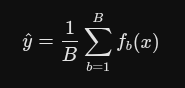

In [ ]:
#importar libreria necesaria
from sklearn.ensemble import RandomForestRegressor

In [ ]:
#definir las variables
X_train_rfr, X_test_rfr,y_train_rfr,y_test_rfr = train_test_split(X,y,test_size=0.15,random_state=42)

In [ ]:
#crear el modelo
rfr = RandomForestRegressor(random_state=13)
#entrenar el modelo
rfr.fit(X_train_rfr,y_train_rfr)

RandomForestRegressor(random_state=13)

In [ ]:
y_pred_rfr = rfr.predict(X_test_rfr)

In [ ]:
#ver metricas
metrics_model(y_test_rfr,y_pred_rfr)

MAE: 3231.148945647732
MSE: 28389496.969453376
RMSE: 5328.179517382403
R2: 0.7759318334596321


## **GradientBoostingRegressor**
El Gradient Boosting Regressor es un algoritmo de aprendizaje supervisado utilizado para predecir valores numéricos mediante la combinación secuencial de múltiples árboles de decisión. A diferencia de Random Forest, este modelo construye cada nuevo árbol con el objetivo de corregir los errores cometidos por los árboles anteriores, mejorando progresivamente la precisión de las predicciones. Gracias a este enfoque, es capaz de capturar relaciones complejas y no lineales entre las variables, ofreciendo un alto rendimiento en problemas de regresión y siendo ampliamente utilizado en la predicción de precios, ventas y otras variables numéricas.

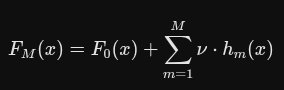

In [ ]:
#importar libreria
from sklearn.ensemble import GradientBoostingRegressor

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
#definir variables
X_train_gbr, X_test_gbr,y_train_gbr,y_test_gbr = train_test_split(X,y,test_size=0.15,random_state=42)

In [ ]:
#crear el modelo
gbr = GradientBoostingRegressor()
#entrenar el modelo
gbr.fit(X_train_gbr,y_train_gbr)

GradientBoostingRegressor()

In [ ]:
#predicciones del modelo
y_pred_gbr = gbr.predict(X_test_gbr)

In [ ]:
#ver las metricas
metrics_model(y_test_gbr,y_pred_gbr)

MAE: 3365.6138217590337
MSE: 29486960.201699972
RMSE: 5430.189702183522
R2: 0.7672699478841479


In [ ]:
import pandas as pd
car = pd.read_csv('data_Car_ML.csv')
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16382 entries, 0 to 16381
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   odometer                16382 non-null  float64
 1   price                   16382 non-null  float64
 2   size                    16382 non-null  float64
 3   title_status            16382 non-null  float64
 4   year                    16382 non-null  int64  
 5   condition_encoding      16382 non-null  float64
 6   cylinders_int           16382 non-null  float64
 7   fuel_diesel             16382 non-null  float64
 8   fuel_electric           16382 non-null  float64
 9   fuel_gas                16382 non-null  float64
 10  fuel_hybrid             16382 non-null  float64
 11  drive_4wd               16382 non-null  float64
 12  drive_fwd               16382 non-null  float64
 13  drive_rwd               16382 non-null  float64
 14  transmission_automatic  16382 non-null